In [1]:
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense
import numpy as np

from hoda_loader import load_hoda

In [2]:
X_train_original, y_train_original, X_test_original, y_test_original = load_hoda()

In [3]:
X_train_original.shape

(1000, 25)

In [4]:
X_test_original.shape

(200, 25)

In [5]:
y_train_original.shape

(1000,)

In [6]:
y_test_original.shape

(200,)

In [7]:
# Preprocessing input data for keras
y_train = keras.utils.to_categorical(y_train_original, num_classes=10)
y_test = keras.utils.to_categorical(y_test_original, num_classes=10)

In [8]:
y_train_original[:5]

array([6, 5, 0, 2, 7], dtype=uint8)

In [9]:
y_train[:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]])

In [10]:
# Normalize the data (0 - 1)
X_train = X_train_original.astype('float32')
X_test = X_test_original.astype('float32')
X_train /= 255
X_test /= 255

In [11]:
# Model architecture
model = Sequential()
model.add(keras.Input(shape=(25,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           1,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,314 (9.04 KB)

 Trainable params: 2,314 (9.04 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# compile model
model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

In [14]:
# fitting
history = model.fit(X_train, y_train, epochs=100, batch_size=64, validation_split=0.2)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 56ms/step - accuracy: 0.1650 - loss: 2.1963 - val_accuracy: 0.3800 - val_loss: 2.0616
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.4412 - loss: 1.9977 - val_accuracy: 0.5500 - val_loss: 1.8987
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5725 - loss: 1.8408 - val_accuracy: 0.6600 - val_loss: 1.7493
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6313 - loss: 1.6900 - val_accuracy: 0.6900 - val_loss: 1.6015
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6787 - loss: 1.5437 - val_accuracy: 0.7200 - val_loss: 1.4618
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7150 - loss: 1.4032 - val_accuracy: 0.7250 - val_loss: 1.3291
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7563 - loss: 1.2705 - val_accuracy: 0.7500 - val_loss: 1.2059
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.7837 - loss: 1.1488 - val_accuracy: 0.

In [16]:
import matplotlib.pyplot as plt

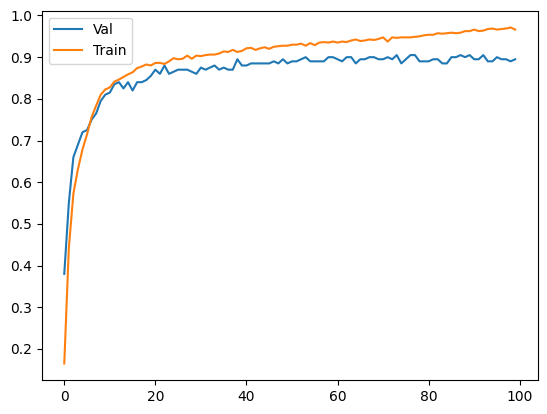

In [22]:
plt.plot(history.history['val_accuracy'])
plt.plot(history.history['accuracy'])
plt.legend(["Val", "Train"]);

In [23]:
# Evaluation model on the test data
loss, acc = model.evaluate(X_test, y_test)
print("\nTesting loss: %.2f, acc: %.2f%%"%(loss, acc))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9250 - loss: 0.2601

Testing loss: 0.26, acc: 0.93%


In [30]:
y_test[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

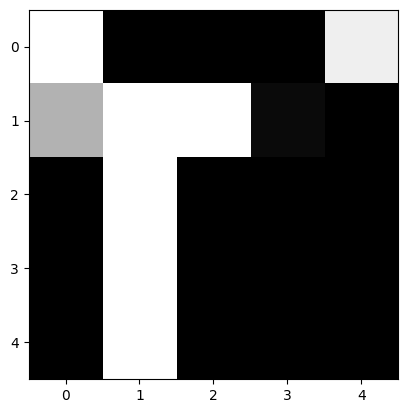

In [34]:
plt.imshow(X_test[1].reshape(5, 5), cmap='gray');

In [29]:
model.predict(X_test)[1].argmax()

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


np.int64(2)

In [36]:
model.predict(X_test).max(axis=1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


array([0.99981016, 0.77636635, 0.9200772 , 0.5085409 , 0.9931403 ,
       0.99350125, 0.9535464 , 0.9564104 , 0.9721637 , 0.7017211 ,
       0.65728337, 0.99993455, 0.8227585 , 0.9996408 , 0.7236328 ,
       0.99537754, 0.81636006, 0.9973688 , 0.72030705, 0.98285323,
       0.995751  , 0.9660622 , 0.99429446, 0.9256769 , 0.958162  ,
       0.9886107 , 0.99986875, 0.99881446, 0.9964837 , 0.9926137 ,
       0.64177495, 0.9970391 , 0.9342664 , 0.9997491 , 0.98507565,
       0.54591715, 0.9991811 , 0.6579547 , 0.99090147, 0.9996232 ,
       0.9803977 , 0.9100704 , 0.55625916, 0.78548455, 0.9974583 ,
       0.97352684, 0.9514705 , 0.81718117, 0.99049485, 0.9726002 ,
       0.9874408 , 0.63002   , 0.98124194, 0.9991636 , 0.64690804,
       0.7510478 , 0.9988801 , 0.9826012 , 0.9860422 , 0.9991059 ,
       0.9794174 , 0.99905866, 0.99729365, 0.998678  , 0.5896829 ,
       0.9902339 , 0.7123709 , 0.80908704, 0.5900475 , 0.9735778 ,
       0.907334  , 0.9997837 , 0.93482435, 0.98095936, 0.98413

In [40]:
np.sum(model.predict(X_test).argmax(axis=1) == y_test.argmax(axis=1)) / len(y_test.argmax(axis=1))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


np.float64(0.925)

In [41]:
np.mean(model.predict(X_test).argmax(axis=1) == y_test.argmax(axis=1))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


np.float64(0.925)